<a href="https://colab.research.google.com/github/Aswathi281099/Generative-Artificial-Intelligence/blob/main/AI_TASK_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TASK 7**

In [1]:
# Install required libraries
!pip install -q -U transformers peft accelerate "bitsandbytes>=0.46.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 20.8 MB/s eta 0:00:00


In [2]:
# Force reinstall the required bitsandbytes version
!pip uninstall -y bitsandbytes
!pip install -q bitsandbytes>=0.46.1

Found existing installation: bitsandbytes 0.50.0
Uninstalling bitsandbytes-0.50.0:
  Successfully uninstalled bitsandbytes-0.50.0


In [3]:
# Check bitsandbytes version
import bitsandbytes as bnb

print("bitsandbytes version:", bnb.__version__)

bitsandbytes version: 0.50.0


In [4]:
# Import PyTorch
import torch
import torch.nn as nn

# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Import Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

# Import PEFT LoRA tools
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType
)

print("Libraries imported successfully.")

# Check GPU
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Libraries imported successfully.
GPU available: True
GPU: Tesla T4


In [5]:
# Create a custom LoRA layer
class LoRALayer(nn.Module):

    def __init__(
        self,
        input_size,
        output_size,
        rank=4,
        alpha=8
    ):
        super().__init__()

        # Store LoRA rank
        self.rank = rank

        # Store scaling factor
        self.alpha = alpha

        # Original weight - frozen
        self.weight = nn.Parameter(
            torch.randn(
                output_size,
                input_size
            ),
            requires_grad=False
        )

        # Low-rank matrix A - trainable
        self.A = nn.Parameter(
            torch.randn(
                rank,
                input_size
            ) * 0.01
        )

        # Low-rank matrix B - trainable
        self.B = nn.Parameter(
            torch.zeros(
                output_size,
                rank
            )
             )

    def forward(self, x):

        # Original transformation
        original = x @ self.weight.T

        # LoRA update
        lora_update = (
            self.alpha / self.rank
        ) * (
            x @ self.A.T @ self.B.T
        )

        # Combine original and LoRA output
        return original + lora_update


print("Custom LoRA layer created.")

Custom LoRA layer created.


In [6]:
# Create LoRA layer
lora_layer = LoRALayer(
    input_size=8,
    output_size=8,
    rank=4,
    alpha=8
)

# Create sample input
x = torch.randn(2, 8)

# Generate output
output = lora_layer(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 8])
Output shape: torch.Size([2, 8])


In [7]:
# Check which parameters are trainable
for name, parameter in lora_layer.named_parameters():

    print(
        name,
        "Trainable:",
        parameter.requires_grad
    )

weight Trainable: False
A Trainable: True
B Trainable: True


In [8]:
# Name of the 3B model
model_name = "Qwen/Qwen2.5-3B"

# Configure 4-bit quantization
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

# Load the 3B model
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto"
)

print("3B model loaded successfully.")

config.json:   0%|          | 0.00/683 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

3B model loaded successfully.


In [9]:
# Configure LoRA
lora_config = LoraConfig(
    r=4,
    lora_alpha=8,
    lora_dropout=0.05,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ],
    task_type=TaskType.CAUSAL_LM
)

# Add LoRA adapters to the model
model = get_peft_model(
    model,
    lora_config
)


In [10]:
# Display trainable parameter information
model.print_trainable_parameters()

trainable params: 1,843,200 || all params: 3,087,781,888 || trainable%: 0.0597


In [11]:
# Create a small domain-specific dataset
training_texts = [
    "Artificial intelligence allows machines to perform intelligent tasks.",
    "Machine learning enables systems to learn patterns from data.",
    "Deep learning uses neural networks to learn complex patterns.",
    "Natural language processing helps computers understand human language."
]

print(
    "Number of training examples:",
    len(training_texts)
)

Number of training examples: 4


In [12]:
# Check the LoRA parameters that will be trained
trainable_parameters = [
    parameter
    for parameter in model.parameters()
    if parameter.requires_grad
]

print(
    "Number of trainable LoRA tensors:",
    len(trainable_parameters)
)

# Verify that LoRA parameters are trainable
for name, parameter in model.named_parameters():

    if parameter.requires_grad:
        print(
            name,
            "Shape:",
            tuple(parameter.shape)
        )

Number of trainable LoRA tensors: 288
base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight Shape: (2048, 4)
base_model.model.model.layers.0.self_attn.k_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.k_proj.lora_B.default.weight Shape: (256, 4)
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight Shape: (256, 4)
base_model.model.model.layers.0.self_attn.o_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.0.self_attn.o_proj.lora_B.default.weight Shape: (2048, 4)
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight Shape: (4, 2048)
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight Shape: (2048, 4)
base_model.model.model.layers.1.self_attn.k_proj.lora_A.default.weight Shape: (4, 20

Frozen parameters: 1698672640
Trainable parameters: 1843200


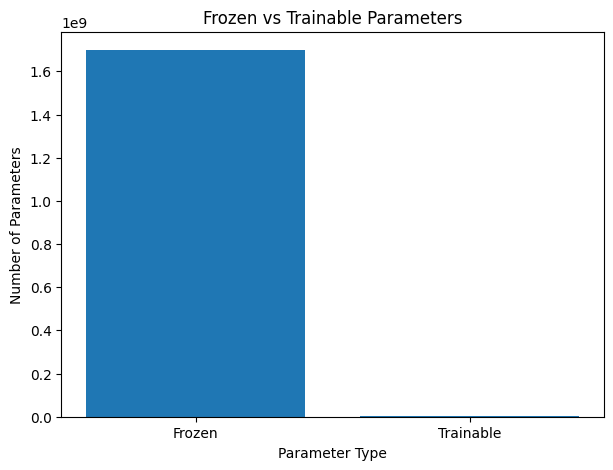

In [13]:
# Count parameters
trainable = 0
frozen = 0

for parameter in model.parameters():

    if parameter.requires_grad:
        trainable += parameter.numel()

    else:
        frozen += parameter.numel()

print("Frozen parameters:", frozen)
print("Trainable parameters:", trainable)

# Create visualization
plt.figure(figsize=(7, 5))

plt.bar(
    ["Frozen", "Trainable"],
    [frozen, trainable]
)

plt.xlabel("Parameter Type")
plt.ylabel("Number of Parameters")
plt.title("Frozen vs Trainable Parameters")

plt.show()

